---
## Flight Volume Heatmap — Day of Week × Time Slot

**Template notebook** — reusable for any corridor, period, or aircraft segment.
Only edit the `CONFIG` cell, then **Kernel → Restart & Run All**.


In [12]:
# ════════════════════════════════════════════════════════
# CONFIG — edit here only
# ════════════════════════════════════════════════════════
from pathlib import Path

RAW_BASE = 'gs://agntworks-data-dev/wheelsup/raw/wingx/WingX'   # GCS base, year + .zip appended
ICAO_CSV = 'gs://agntworks-data-dev/sandbox/experiments/icao_cluster.csv'

YEARS = [2025]                        # list of years to load

START_DT_ET = '2025-04-01'           # inclusive, Eastern time
END_DT_ET   = '2025-06-01'           # exclusive, Eastern time

FROM_CLUSTER   = 'MIAMI_CLUSTER'     # must match icao_cluster.csv
TO_CLUSTER     = 'NEW_YORK_CLUSTER'
CORRIDOR_LABEL = 'Miami → New York'

AIRCRAFT_SEGMENT = 'Light Jet'       # set None for all segments

OUTPUT_PNG = 'heatmap_output.png'

RELOAD_DATA = True   # set False to skip re-loading df (reuse existing)
# ════════════════════════════════════════════════════════


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import fsspec
from zipfile import ZipFile
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

def load_specific_csv_from_zip(url, filename):
    with fsspec.open(url, 'rb') as f:
        with ZipFile(BytesIO(f.read())) as z:
            return pd.read_csv(z.open(filename))

QUARTER_FILES = {
    2023: ['WINGX_Jan23-Mar23.csv','WINGX_Apr23-Jun23.csv','WINGX_Jul23-Sep23.csv','WINGX_Oct23-Dec23.csv'],
    2024: ['WINGX_Jan24-Mar24.csv','WINGX_Apr24-Jun24.csv','WINGX_Jul24-Sep24.csv','WINGX_Oct24-Dec24.csv'],
    2025: ['WINGX_Jan25-Mar25.csv','WINGX_Apr25-Jun25.csv','WINGX_Jul25-Sep25.csv','WINGX_Oct25-Dec25.csv'],
    2026: ['WINGX_Jan26-Mar26.csv'],
}

if RELOAD_DATA or 'df' not in dir():
    frames = []
    for yr in YEARS:
        url = f'{RAW_BASE}_{yr}.zip'
        for fname in QUARTER_FILES[yr]:
            frames.append(load_specific_csv_from_zip(url, fname))
            print(f'  Loaded: {fname}')

    df = pd.concat(frames, ignore_index=True)
    df['FlightDate_utc']  = pd.to_datetime(df['FlightDate_utc'])
    df['ArrivalDate_utc'] = pd.to_datetime(df['ArrivalDate_utc'], errors='coerce')
    df['FromState'] = df['FromState'].fillna('International/Unknown')
    df['ToState']   = df['ToState'].fillna('International/Unknown')

    icao_map    = pd.read_csv(ICAO_CSV)
    cluster_map = dict(zip(icao_map['icao'], icao_map['cluster']))
    df['from_cluster'] = df['FromAirport'].map(cluster_map).fillna('Other')
    df['to_cluster']   = df['ToAirport'].map(cluster_map).fillna('Other')

    is_short = df['Hours'] <= 0.5
    is_hub   = (df['from_cluster'] == df['to_cluster']) & (df['from_cluster'] != 'Other') & (df['Hours'] <= 1.0)
    df['reposition_flight'] = np.where(is_short | is_hub, 'Y', 'N')

    print(f'Loaded. Total rows: {len(df):,}')
else:
    print(f'Reusing existing df ({len(df):,} rows). Set RELOAD_DATA=True to reload.')


  Loaded: WINGX_Jan25-Mar25.csv
  Loaded: WINGX_Apr25-Jun25.csv
  Loaded: WINGX_Jul25-Sep25.csv
  Loaded: WINGX_Oct25-Dec25.csv
Loaded. Total rows: 3,636,777


In [14]:
start_dt = pd.Timestamp(START_DT_ET, tz='US/Eastern')
end_dt   = pd.Timestamp(END_DT_ET,   tz='US/Eastern')

mask = (
    (df['FlightDate_utc'] >= start_dt) & (df['FlightDate_utc'] < end_dt) &
    (df['from_cluster'] == FROM_CLUSTER) &
    (df['to_cluster']   == TO_CLUSTER) &
    (df['reposition_flight'] == 'N')
)
if AIRCRAFT_SEGMENT:
    mask = mask & (df['aircraft_segment'] == AIRCRAFT_SEGMENT)

df_mia_ny = df[mask].copy()
segment_label = AIRCRAFT_SEGMENT if AIRCRAFT_SEGMENT else 'All Segments'
print(f'{CORRIDOR_LABEL} | {segment_label} | {START_DT_ET} → {END_DT_ET}')
print(f'Revenue flights: {len(df_mia_ny):,}')

df_mia_ny['dt_et']    = df_mia_ny['FlightDate_utc'].dt.tz_convert('US/Eastern')
df_mia_ny['hour']     = df_mia_ny['dt_et'].dt.hour
df_mia_ny['dow']      = df_mia_ny['dt_et'].dt.dayofweek

def assign_slot(h):
    if   7  <= h < 10: return '1: 7am-10am'
    elif 10 <= h < 13: return '2: 10am-1pm'
    elif 13 <= h < 16: return '3: 1pm-4pm'
    elif 16 <= h < 19: return '4: 4pm-7pm'
    elif 19 <= h < 22: return '5: 7pm-10pm'
    elif h >= 22 or h < 1: return '6: 10pm-1am'
    else: return 'Other'

dow_labels = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
df_mia_ny['slot']      = df_mia_ny['hour'].apply(assign_slot)
df_mia_ny['dow_label'] = df_mia_ny['dow'].map(dow_labels)

DOW_ORDER  = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
SLOT_ORDER = ['1: 7am-10am','2: 10am-1pm','3: 1pm-4pm',
              '4: 4pm-7pm','5: 7pm-10pm','6: 10pm-1am','Other']

WU_LIST = ['Wheels Up Private Jets','Wheels Up LLC','Mountain Aviation','Alante Air Charter']
def assign_operator(op):
    op = str(op)
    if 'NetJets'  in op: return 'NetJets'
    if 'Flexjet'  in op: return 'Flexjet'
    if 'VistaJet' in op: return 'VistaJet'
    if op in WU_LIST:    return 'Wheels Up'
    return 'Other'

df_mia_ny['operator_group'] = df_mia_ny['Operator'].apply(assign_operator)

print('\nOperator group counts:')
print(df_mia_ny['operator_group'].value_counts().to_string())
print('\nSlot distribution:')
print(df_mia_ny['slot'].value_counts().sort_index().to_string())


Miami → New York | Light Jet | 2025-04-01 → 2025-06-01
Revenue flights: 597

Operator group counts:
operator_group
Other        377
NetJets      134
Flexjet       55
Wheels Up     31

Slot distribution:
slot
1: 7am-10am    142
2: 10am-1pm    217
3: 1pm-4pm     132
4: 4pm-7pm      63
5: 7pm-10pm     17
6: 10pm-1am      9
Other           17


In [15]:
def make_heatmap(subset, title, ax):
    """Build DOW × Slot heatmap with totals row/col like reference image."""
    pivot = (
        subset.groupby(['slot','dow_label'])
        .size()
        .unstack('dow_label')
        .reindex(index=SLOT_ORDER, columns=DOW_ORDER)
        .fillna(0)
        .astype(int)
    )

    # Add totals
    pivot['TOTAL'] = pivot.sum(axis=1)
    totals_row     = pivot.sum(axis=0).to_frame().T
    totals_row.index = ['TOTAL']
    heat_data = pd.concat([totals_row, pivot])

    # Colormap: green → yellow → red (like reference)
    cmap = LinearSegmentedColormap.from_list(
        'gyr', ['#63BE7B','#FFEB84','#F8696B'])

    # Separate color scale: totals row vs body (avoid totals dominating)"""  """
    body   = heat_data.iloc[1:].values.astype(float)
    vmax   = body.max() if body.max() > 0 else 1

    sns.heatmap(
        heat_data, annot=True, fmt='d', cmap=cmap,
        linewidths=0.5, linecolor='white',
        vmin=0, vmax=vmax,
        ax=ax, cbar=False,
        annot_kws={'size': 9, 'weight': 'bold'}
    )

    ax.set_title(title, fontsize=12, fontweight='bold', pad=10,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='#1a1a2e', edgecolor='white'),
                 color='white')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=8, rotation=0)

    # Highlight TOTAL row with darker border
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    n_flights = len(subset)
    ax.set_xlabel(f'n = {n_flights:,} flights', fontsize=8, labelpad=6)


operator_group counts:
operator_group
Other        377
NetJets      134
Flexjet       55
Wheels Up     31


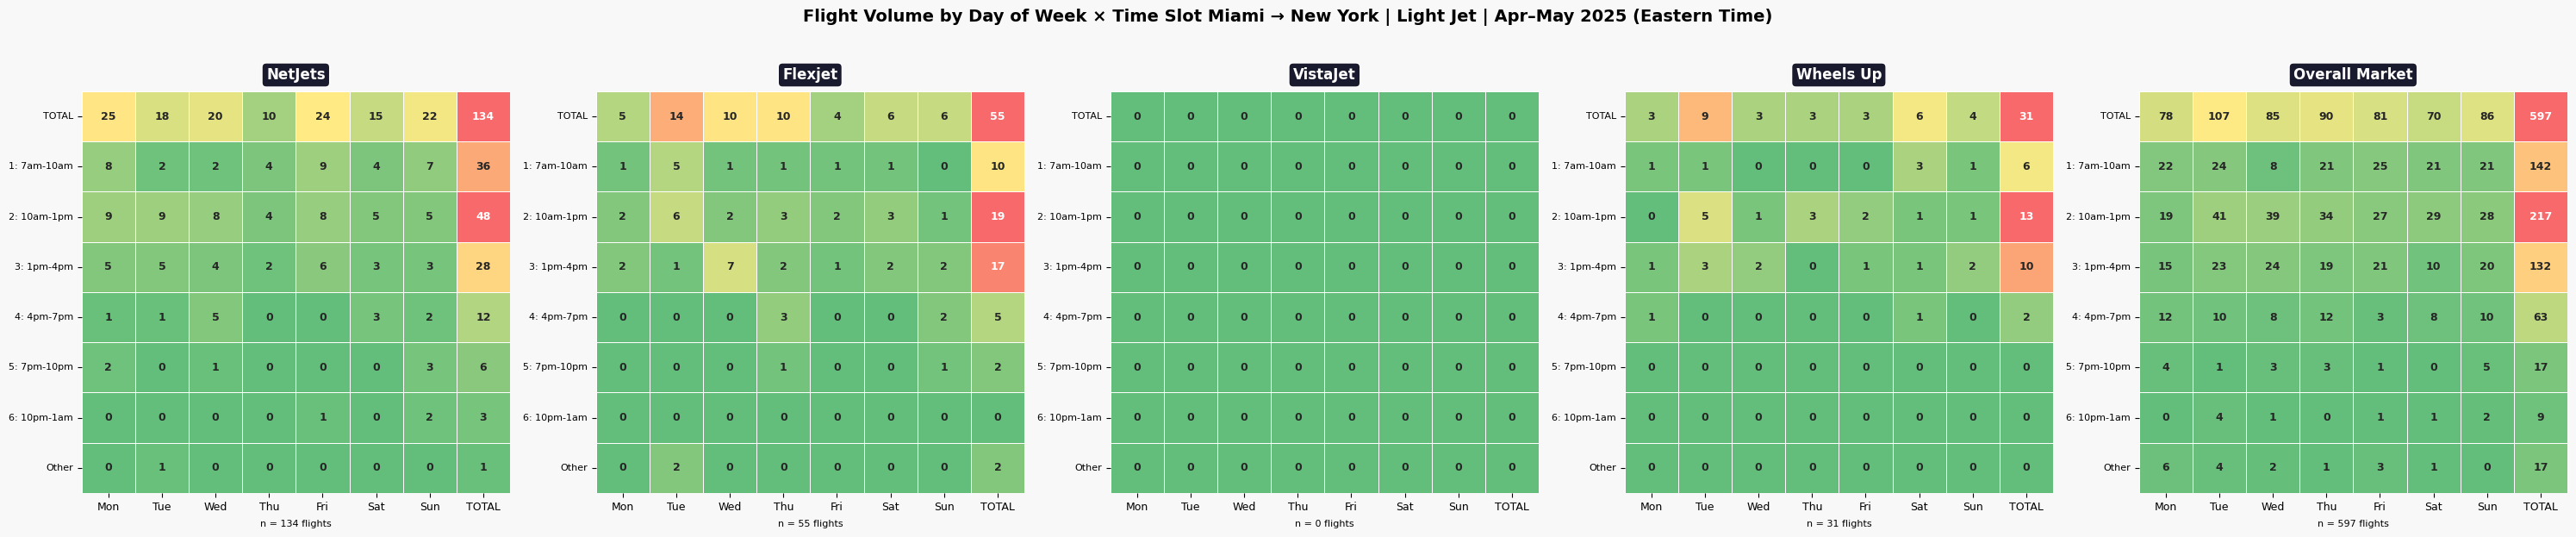

Saved: heatmap_mia_ny_light_jet_apr_may_2025.png


In [16]:
# Re-apply operator group to ensure correct labels
WU_LIST = ["Wheels Up Private Jets","Wheels Up LLC","Mountain Aviation","Alante Air Charter"]
def assign_operator(op):
    op = str(op)
    if "NetJets"  in op: return "NetJets"
    if "Flexjet"  in op: return "Flexjet"
    if "VistaJet" in op: return "VistaJet"
    if op in WU_LIST:    return "Wheels Up"
    return "Other"

df_mia_ny["operator_group"] = df_mia_ny["Operator"].apply(assign_operator)
print("operator_group counts:")
print(df_mia_ny["operator_group"].value_counts().to_string())

operator_configs = [
    ("NetJets",       df_mia_ny[df_mia_ny["operator_group"] == "NetJets"]),
    ("Flexjet",       df_mia_ny[df_mia_ny["operator_group"] == "Flexjet"]),
    ("VistaJet",      df_mia_ny[df_mia_ny["operator_group"] == "VistaJet"]),
    ("Wheels Up",     df_mia_ny[df_mia_ny["operator_group"] == "Wheels Up"]),
    ("Overall Market",df_mia_ny),
]

fig, axes = plt.subplots(1, 5, figsize=(30, 6))
fig.patch.set_facecolor("#f8f8f8")

for ax, (name, subset) in zip(axes, operator_configs):
    make_heatmap(subset, name, ax)

plt.suptitle("Flight Volume by Day of Week × Time Slot Miami → New York | Light Jet | Apr–May 2025 (Eastern Time)",
    fontsize=14, fontweight="bold", y=1.03
)
plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight", facecolor="#f8f8f8")
plt.show()
print("Saved: heatmap_mia_ny_light_jet_apr_may_2025.png")


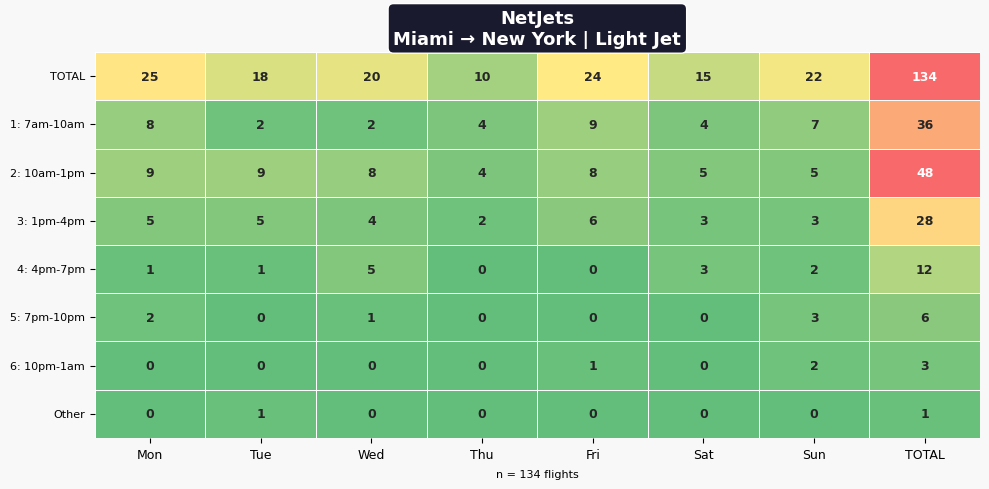

Saved: heatmap_netjets_miami_to_newyork.png


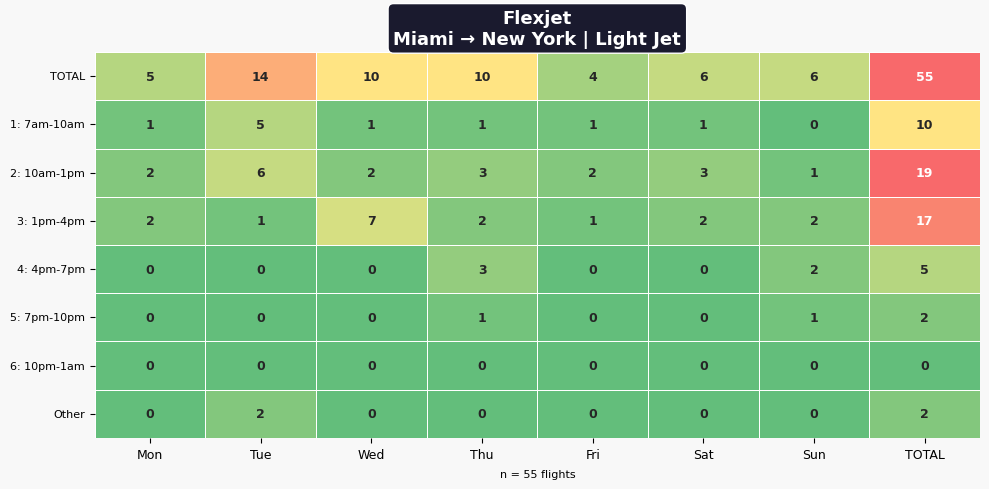

Saved: heatmap_flexjet_miami_to_newyork.png


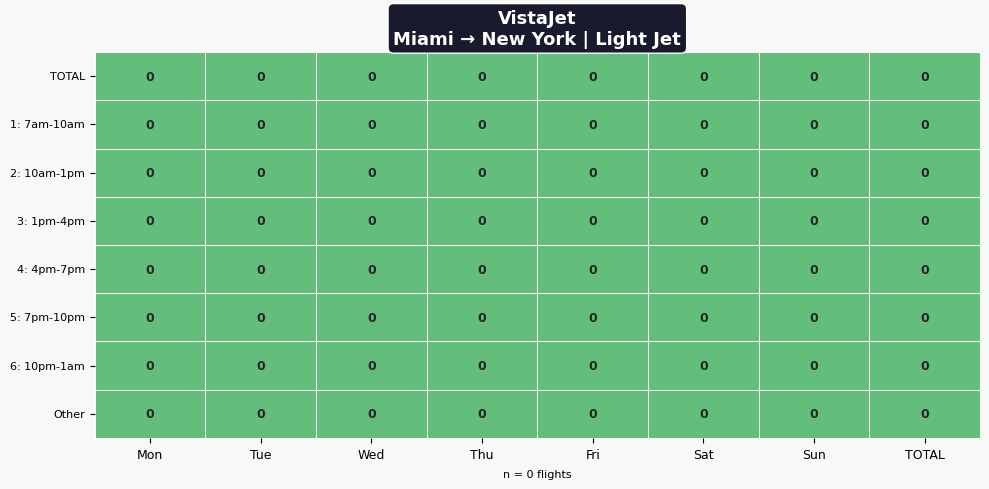

Saved: heatmap_vistajet_miami_to_newyork.png


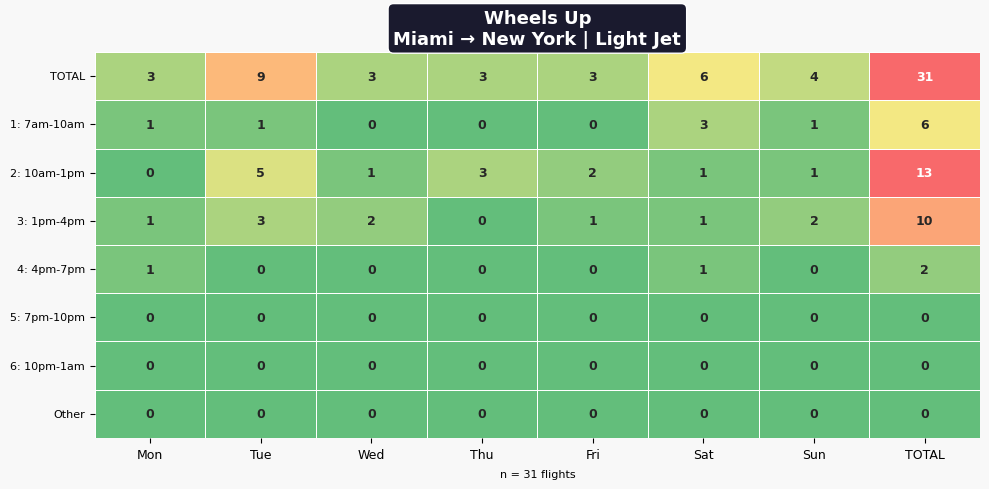

Saved: heatmap_wheels_up_miami_to_newyork.png


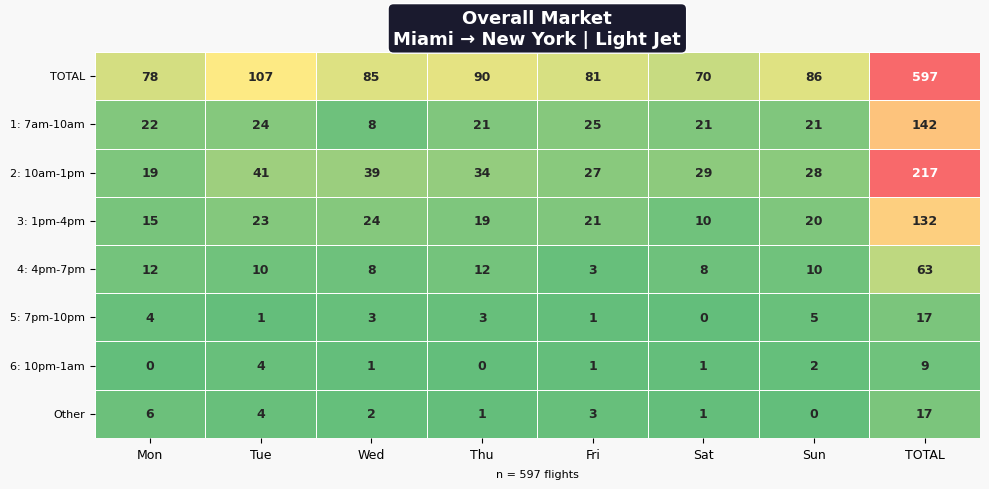

Saved: heatmap_overall_market_miami_to_newyork.png


In [17]:
# Individual full-size heatmaps for detailed reading
for name, subset in operator_configs:
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.patch.set_facecolor('#f8f8f8')
    make_heatmap(subset, name, ax)
    plt.title(
        f'{name}\n{CORRIDOR_LABEL} | {segment_label}',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    fname = f'heatmap_{name.lower().replace(" ","_")}_{CORRIDOR_LABEL.lower().replace(" ","").replace("→","_to_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#f8f8f8')
    plt.show()
    print(f'Saved: {fname}')


In [18]:
# Quick check — full loaded data, key operators, month-wise
TARGET_OPS = ['NetJets', 'Flexjet', 'VistaJet', 'Wheels Up']

WU_LIST = ['Wheels Up Private Jets','Wheels Up LLC','Mountain Aviation','Alante Air Charter']
def assign_operator(op):
    op = str(op)
    if 'NetJets'  in op: return 'NetJets'
    if 'Flexjet'  in op: return 'Flexjet'
    if 'VistaJet' in op: return 'VistaJet'
    if op in WU_LIST:    return 'Wheels Up'
    return 'Other'

df['operator_group'] = df['Operator'].apply(assign_operator)

seg_mask = (df['aircraft_segment'] == AIRCRAFT_SEGMENT) if AIRCRAFT_SEGMENT else pd.Series([True]*len(df), index=df.index)
df_lj = df[seg_mask & (df['reposition_flight'] == 'N')].copy()

segment_label = AIRCRAFT_SEGMENT if AIRCRAFT_SEGMENT else 'All Segments'
print(f'=== {segment_label} | All Loaded Years (Revenue) ===')
print(f'Total: {len(df_lj):,}')
print()
print(df_lj['operator_group'].value_counts().loc[lambda x: x.index.isin(TARGET_OPS)].to_string())

df_lj['month_name'] = df_lj['FlightDate_utc'].dt.strftime('%b')
df_lj['month_num']  = df_lj['FlightDate_utc'].dt.month
df_lj['year']       = df_lj['FlightDate_utc'].dt.year

monthly = (
    df_lj[df_lj['operator_group'].isin(TARGET_OPS)]
    .groupby(['year','month_num','month_name','operator_group'])
    .size()
    .reset_index(name='flights')
    .pivot(index=['year','month_num','month_name'], columns='operator_group', values='flights')
    .fillna(0).astype(int)
    .sort_index()
)
monthly.index = [f'{y}-{m}' for y,_,m in monthly.index]
for op in TARGET_OPS:
    if op not in monthly.columns: monthly[op] = 0
monthly = monthly[TARGET_OPS]
monthly['TOTAL'] = monthly.sum(axis=1)

print(f'\n=== Month-wise {segment_label} — Key Operators ===')
display(monthly)


=== Light Jet | All Loaded Years (Revenue) ===
Total: 666,654

operator_group
NetJets      85149
Flexjet      36257
Wheels Up    22226
VistaJet         2

=== Month-wise Light Jet — Key Operators ===


operator_group,NetJets,Flexjet,VistaJet,Wheels Up,TOTAL
2025-Jan,5912,2546,0,1507,9965
2025-Feb,6024,2695,0,1441,10160
2025-Mar,6842,3003,0,1817,11662
2025-Apr,6854,3060,0,1801,11715
2025-May,7571,3260,0,1923,12754
2025-Jun,7473,3092,0,2059,12624
2025-Jul,7274,3036,0,2045,12355
2025-Aug,7145,3078,0,1981,12204
2025-Sep,7618,3082,0,1776,12476
2025-Oct,8163,3380,2,1950,13495


In [19]:
# Quick check — corridor route, key operators, month-wise
TARGET_OPS = ['NetJets', 'Flexjet', 'VistaJet', 'Wheels Up']

WU_LIST = ['Wheels Up Private Jets','Wheels Up LLC','Mountain Aviation','Alante Air Charter']
def assign_operator(op):
    op = str(op)
    if 'NetJets'  in op: return 'NetJets'
    if 'Flexjet'  in op: return 'Flexjet'
    if 'VistaJet' in op: return 'VistaJet'
    if op in WU_LIST:    return 'Wheels Up'
    return 'Other'

df['operator_group'] = df['Operator'].apply(assign_operator)

seg_mask = (df['aircraft_segment'] == AIRCRAFT_SEGMENT) if AIRCRAFT_SEGMENT else pd.Series([True]*len(df), index=df.index)
df_route = df[
    seg_mask &
    (df['reposition_flight'] == 'N') &
    (df['from_cluster'] == FROM_CLUSTER) &
    (df['to_cluster']   == TO_CLUSTER)
].copy()

segment_label = AIRCRAFT_SEGMENT if AIRCRAFT_SEGMENT else 'All Segments'
print(f'=== {CORRIDOR_LABEL} | {segment_label} | All Loaded Years (Revenue) ===')
print(f'Total route flights: {len(df_route):,}')
print()
print(df_route['operator_group'].value_counts().loc[lambda x: x.index.isin(TARGET_OPS)].to_string())

df_route['month_name'] = df_route['FlightDate_utc'].dt.strftime('%b')
df_route['month_num']  = df_route['FlightDate_utc'].dt.month
df_route['year']       = df_route['FlightDate_utc'].dt.year

monthly_route = (
    df_route[df_route['operator_group'].isin(TARGET_OPS)]
    .groupby(['year','month_num','month_name','operator_group'])
    .size()
    .reset_index(name='flights')
    .pivot(index=['year','month_num','month_name'], columns='operator_group', values='flights')
    .fillna(0).astype(int)
    .sort_index()
)
monthly_route.index = [f'{y}-{m}' for y,_,m in monthly_route.index]
for op in TARGET_OPS:
    if op not in monthly_route.columns: monthly_route[op] = 0
monthly_route = monthly_route[TARGET_OPS]
monthly_route['TOTAL'] = monthly_route.sum(axis=1)

print(f'\n=== Month-wise: {CORRIDOR_LABEL} | {segment_label} | Key Operators ===')
display(monthly_route)


=== Miami → New York | Light Jet | All Loaded Years (Revenue) ===
Total route flights: 2,860

operator_group
NetJets      611
Flexjet      273
Wheels Up    139

=== Month-wise: Miami → New York | Light Jet | Key Operators ===


operator_group,NetJets,Flexjet,VistaJet,Wheels Up,TOTAL
2025-Jan,74,38,0,10,122
2025-Feb,68,39,0,9,116
2025-Mar,75,29,0,13,117
2025-Apr,62,30,0,11,103
2025-May,73,25,0,20,118
2025-Jun,38,10,0,14,62
2025-Jul,22,7,0,7,36
2025-Aug,24,12,0,7,43
2025-Sep,24,6,0,7,37
2025-Oct,31,19,0,6,56
